# ORD Review Notebook
This notebook reviews the updated ordering harness against the ORD goals in `TLM_PLAN.md`.

Expected qualitative checks:
- release-heavy traffic should reduce throughput as the release ratio rises
- deep writes should drain more slowly than shallow writes
- acquire holds should show a visible latency tail
- `ORD-05` domain 1 should stay close to its relaxed baseline even while domain 0 is held
- all `ORD-C01` through `ORD-C06` checks should pass


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

plt.style.use("seaborn-v0_8-whitegrid")

root = Path(".")
csv_dir = root / "csv"
plot_dir = root / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

impact = pd.read_csv(csv_dir / "ordering_impact.csv")
tx = pd.read_csv(csv_dir / "ordering_transactions.csv")
scan = pd.read_csv(csv_dir / "ordering_scan.csv")
checks = pd.read_csv(csv_dir / "ordering_correctness.csv")
latency = pd.read_csv(csv_dir / "latency_cdf.csv")
ord_dom = pd.read_csv(csv_dir / "ord_domain_trace.csv")
credit = pd.read_csv(csv_dir / "credit_trace.csv")

for frame, cols in [
    (impact, ["release_ratio", "acquire_ratio", "throughput_ordered", "throughput_baseline", "avg_drain_latency_ns", "avg_hold_latency_ns", "domains"]),
    (tx, ["release_drain_ns", "acquire_hold_ns", "reply_done_ns", "ord_dom_id"]),
    (scan, ["param_value", "normalized_throughput", "avg_release_drain_ns", "avg_acquire_hold_ns", "avg_outstanding"]),
    (latency, ["latency_ns", "cdf"]),
    (ord_dom, ["time_ns", "ord_dom_id", "accepted_writes", "outstanding_writes", "outstanding_txns", "last_issued_epoch", "last_retired_epoch"]),
    (credit, ["time_ns", "used", "total", "utilization"]),
]:
    for col in cols:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

def ecdf(values):
    ordered = pd.Series(sorted(float(v) for v in values if pd.notna(v)))
    if ordered.empty:
        return pd.DataFrame(columns=["x", "cdf"])
    return pd.DataFrame({"x": ordered, "cdf": (ordered.index + 1) / len(ordered)})

impact[["experiment", "overhead_pct", "avg_drain_latency_ns", "avg_hold_latency_ns", "domains"]]


,experiment,overhead_pct,avg_drain_latency_ns,avg_hold_latency_ns,domains
0,ORD-01,0.033292,1.042553,0.000000,1
1,ORD-02,27.519917,53.277419,0.000000,1
2,ORD-03,0.000000,0.000000,9.000000,1
3,ORD-04,1.106016,109.586423,321.780087,1
4,ORD-05,0.000000,0.000000,9.000000,2
5,ORD-06,0.231066,31.312193,232.824170,4
6,ORD-07,6.098038,2.365154,0.000000,1
7,ORD-08,1.277991,145.981577,326.970382,1


## Release Ratio Sweep
Architecture and networking papers typically show pressure curves as normalized throughput versus one swept parameter.
The main check here is that the deep-write curve drops earlier than the shallow-write curve.


## Review Equations
\[
\eta=
rac{T_	ext{ordered}}{T_	ext{baseline}}
\]
normalized throughput \(\eta\) is one minus overhead in this notebook.

\[
\hat F_X(x)=
rac{1}{N}\sum_{i=1}^{N}\mathbf{1}\left(X_i\le x
ight)
\]
This is the empirical CDF used in stall-distribution plots.

\[
E[D_	ext{release}]=\mathbb E\left[
rac{\sum d_i^	ext{release}}{N_	ext{release}}
ight],\quad
T^{-1}=T_0^{-1}+
rac{E[D_	ext{release}]+E[D_	ext{acquire}] + 	au_0}{B}
\]
Release drain and acquire hold raise service time, then lower throughput; this is the primary release-drain reasoning.


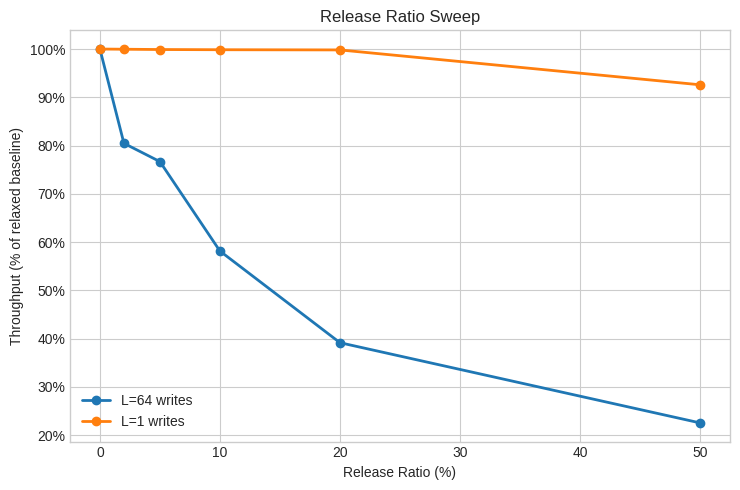

{'shallow_50pct_release': 0.9259045419553502, 'deep_50pct_release': 0.2252611102105092, 'deep_curve_is_lower': True}


In [2]:
release_scan = scan[scan["family"].isin(["release_shallow_scan", "release_deep_scan"])].copy()
labels = {"release_shallow_scan": "L=1 writes", "release_deep_scan": "L=64 writes"}
plt.figure(figsize=(7.5, 5))
for family, group in release_scan.groupby("family"):
    group = group.sort_values("param_value")
    plt.plot(group["param_value"] * 100.0, group["normalized_throughput"] * 100.0, marker="o", linewidth=2.0, label=labels[family])
plt.xlabel("Release Ratio (%)")
plt.ylabel("Throughput (% of relaxed baseline)")
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.title("Release Ratio Sweep")
plt.legend()
out = plot_dir / "ordering_release_ratio_scan.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

shallow_50 = float(release_scan[(release_scan["family"] == "release_shallow_scan") & (release_scan["param_value"] == 0.50)]["normalized_throughput"].iloc[0])
deep_50 = float(release_scan[(release_scan["family"] == "release_deep_scan") & (release_scan["param_value"] == 0.50)]["normalized_throughput"].iloc[0])
print({"shallow_50pct_release": shallow_50, "deep_50pct_release": deep_50, "deep_curve_is_lower": deep_50 < shallow_50})


## Throughput and Mean Stall Components
Same experiments are projected into mean latency components to expose whether throughput loss is release-driven or acquire-driven.


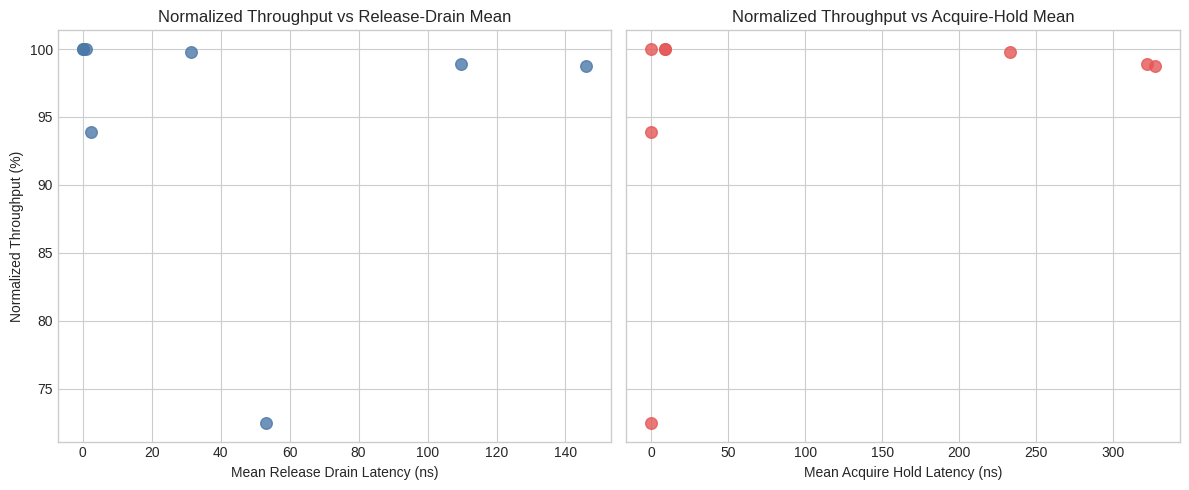

  experiment  normalized_throughput  release_drain_fraction
0     ORD-01               0.999667                1.000000
1     ORD-02               0.724801                1.000000
2     ORD-03               1.000000                0.000000
3     ORD-04               0.988940                0.254045
4     ORD-05               1.000000                0.000000
5     ORD-06               0.997689                0.118546
6     ORD-07               0.939020                1.000000
7     ORD-08               0.987220                0.308660


In [3]:
impact_perf = impact.dropna(
    subset=["throughput_ordered", "throughput_baseline", "avg_drain_latency_ns", "avg_hold_latency_ns"]
).copy()
impact_perf["normalized_throughput"] = impact_perf["throughput_ordered"] / impact_perf["throughput_baseline"]
if impact_perf.empty:
    print("No impact rows available for stall-component plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    axes[0].scatter(
        impact_perf["avg_drain_latency_ns"],
        impact_perf["normalized_throughput"] * 100.0,
        s=70,
        alpha=0.8,
        color="#4c78a8",
    )
    axes[0].set_xlabel("Mean Release Drain Latency (ns)")
    axes[0].set_ylabel("Normalized Throughput (%)")
    axes[0].set_title("Normalized Throughput vs Release-Drain Mean")

    axes[1].scatter(
        impact_perf["avg_hold_latency_ns"],
        impact_perf["normalized_throughput"] * 100.0,
        s=70,
        alpha=0.8,
        color="#e45756",
    )
    axes[1].set_xlabel("Mean Acquire Hold Latency (ns)")
    axes[1].set_title("Normalized Throughput vs Acquire-Hold Mean")

    plt.tight_layout()
    out = plot_dir / "ordering_stall_component_scatter.png"
    plt.savefig(out, dpi=180)
    plt.show()

    impact_perf["release_drain_fraction"] = impact_perf["avg_drain_latency_ns"] / (
        impact_perf["avg_drain_latency_ns"] + impact_perf["avg_hold_latency_ns"]
    )
    print(impact_perf[["experiment", "normalized_throughput", "release_drain_fraction"]].head(10))


## Acquire Ratio Sweep
This should show a gentler drop than the release-heavy write case, but it should not stay perfectly flat once acquire points are common.


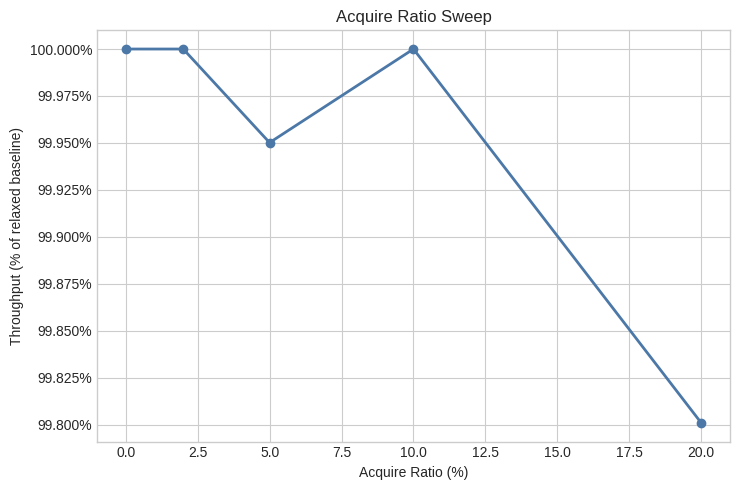

    param_value  normalized_throughput  avg_acquire_hold_ns
12         0.00               1.000000                  0.0
13         0.02               1.000000                  9.0
14         0.05               0.999501                  9.0
15         0.10               1.000000                  9.0
16         0.20               0.998009                  9.0


In [4]:
acquire_scan = scan[scan["family"] == "acquire_scan"].sort_values("param_value")
plt.figure(figsize=(7.5, 5))
plt.plot(acquire_scan["param_value"] * 100.0, acquire_scan["normalized_throughput"] * 100.0, marker="o", linewidth=2.0, color="#4c78a8")
plt.xlabel("Acquire Ratio (%)")
plt.ylabel("Throughput (% of relaxed baseline)")
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.title("Acquire Ratio Sweep")
out = plot_dir / "ordering_acquire_ratio_scan.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

print(acquire_scan[["param_value", "normalized_throughput", "avg_acquire_hold_ns"]])


## Release Drain Latency CDF
A CDF is the right view for stall distributions because a mean alone hides the long drain tail.


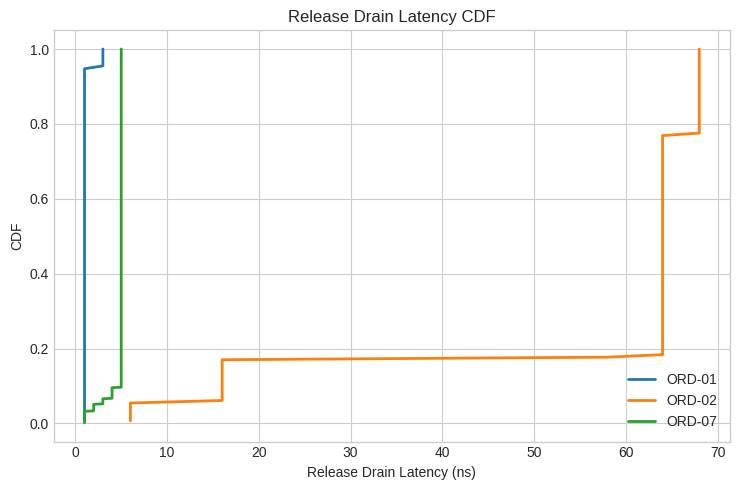

,p50_ns,p95_ns,max_ns
experiment,,,
ORD-01,1.000000,1.800000,3.000000
ORD-02,64.000000,68.000000,68.000000
ORD-04,188.653848,450.978292,483.148504
ORD-06,133.416812,345.437014,421.499473
ORD-07,5.000000,5.000000,5.000000
ORD-08,231.408864,479.068528,494.208632


In [5]:
release_rows = tx[(tx["run_tag"] == "ordered") & (tx["order"] == "release") & (tx["release_drain_ns"] > 0)]
focus = ["ORD-01", "ORD-02", "ORD-07"]
plt.figure(figsize=(7.5, 5))
for experiment in focus:
    group = release_rows[release_rows["experiment"] == experiment]
    curve = ecdf(group["release_drain_ns"])
    if curve.empty:
        continue
    plt.plot(curve["x"], curve["cdf"], linewidth=2.0, label=experiment)
plt.xlabel("Release Drain Latency (ns)")
plt.ylabel("CDF")
plt.title("Release Drain Latency CDF")
plt.legend()
out = plot_dir / "ordering_release_drain_cdf.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

pd.DataFrame({
    "p50_ns": release_rows.groupby("experiment")["release_drain_ns"].median(),
    "p95_ns": release_rows.groupby("experiment")["release_drain_ns"].quantile(0.95),
    "max_ns": release_rows.groupby("experiment")["release_drain_ns"].max(),
})


## Acquire Hold Latency CDF
The acquire tail should be visible, especially for `ORD-06` where ordering and latency variance interact.


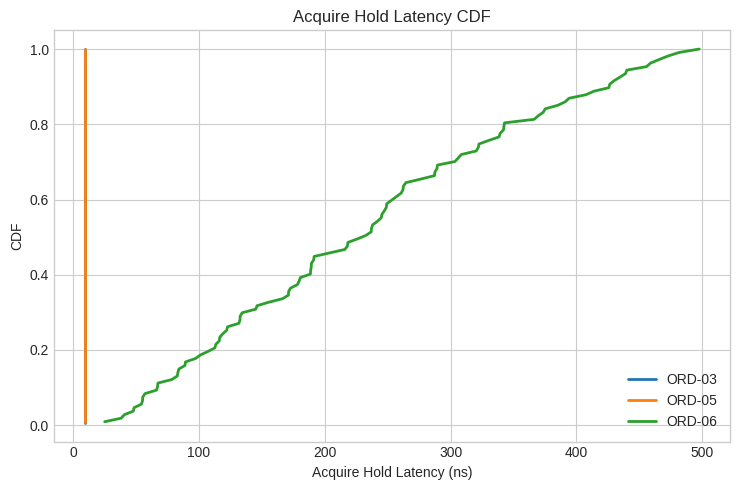

,p50_ns,p95_ns,max_ns
experiment,,,
ORD-03,9.000000,9.000000,9.000000
ORD-04,317.618162,462.877411,498.927076
ORD-05,9.000000,9.000000,9.000000
ORD-06,232.719207,451.133175,497.712501
ORD-08,325.851058,507.697184,520.502061


In [6]:
acquire_rows = tx[(tx["run_tag"] == "ordered") & (tx["order"] == "acquire") & (tx["acquire_hold_ns"] > 0)]
focus = ["ORD-03", "ORD-05", "ORD-06"]
plt.figure(figsize=(7.5, 5))
for experiment in focus:
    group = acquire_rows[acquire_rows["experiment"] == experiment]
    curve = ecdf(group["acquire_hold_ns"])
    if curve.empty:
        continue
    plt.plot(curve["x"], curve["cdf"], linewidth=2.0, label=experiment)
plt.xlabel("Acquire Hold Latency (ns)")
plt.ylabel("CDF")
plt.title("Acquire Hold Latency CDF")
plt.legend()
out = plot_dir / "ordering_acquire_hold_cdf.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

pd.DataFrame({
    "p50_ns": acquire_rows.groupby("experiment")["acquire_hold_ns"].median(),
    "p95_ns": acquire_rows.groupby("experiment")["acquire_hold_ns"].quantile(0.95),
    "max_ns": acquire_rows.groupby("experiment")["acquire_hold_ns"].max(),
})


## End-To-End Latency CDF
Ordered traffic should shift right versus the relaxed baseline for release-heavy cases.
This is the architecture-paper view of total service impact, not just the barrier-local stall term.


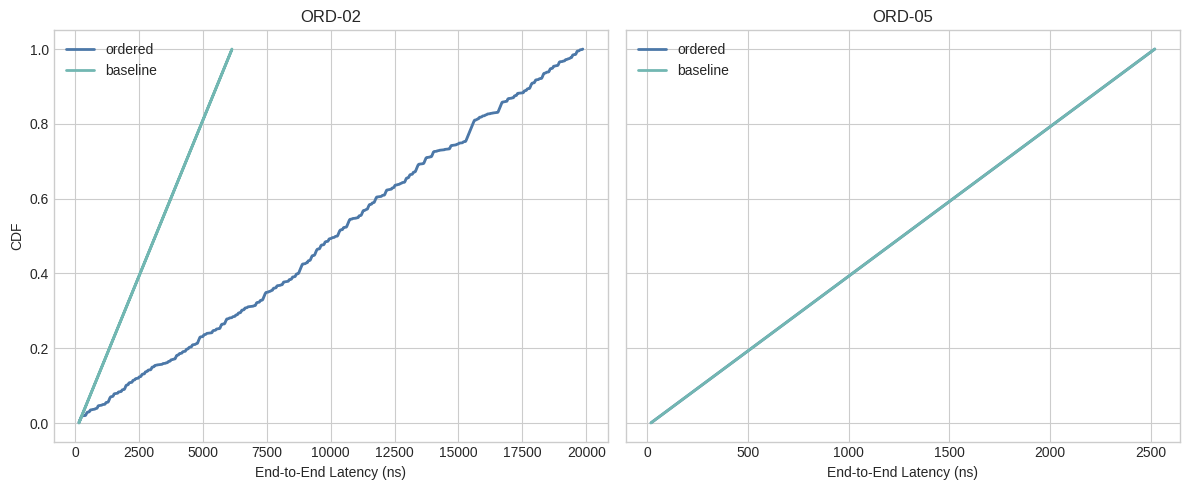

median       p95      max
experiment tag                                 
ORD-02     baseline   3135.0   5829.60   6129.0
           ordered   10262.0  18693.30  19867.0
ORD-05     baseline   1269.5   2394.05   2519.0
           ordered    1269.5   2394.05   2519.0

In [7]:
focus = latency[latency["experiment"].isin(["ORD-02", "ORD-05"])].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for axis, experiment in zip(axes, ["ORD-02", "ORD-05"]):
    group = focus[focus["experiment"] == experiment]
    for tag, color in [("ordered", "#4c78a8"), ("baseline", "#72b7b2")]:
        view = group[group["tag"] == tag]
        if view.empty:
            continue
        axis.plot(view["latency_ns"], view["cdf"], linewidth=2.0, label=tag, color=color)
    axis.set_title(experiment)
    axis.set_xlabel("End-to-End Latency (ns)")
    axis.legend()
axes[0].set_ylabel("CDF")
out = plot_dir / "ordering_end_to_end_latency_cdf.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

display(
    focus.groupby(["experiment", "tag"])["latency_ns"].agg(["median", lambda s: s.quantile(0.95), "max"]).rename(
        columns={"<lambda_0>": "p95"}
    )
)


## Cross-Domain Independence
`ORD-05` should show domain 1 tracking its relaxed baseline while domain 0 slows under acquire holds.


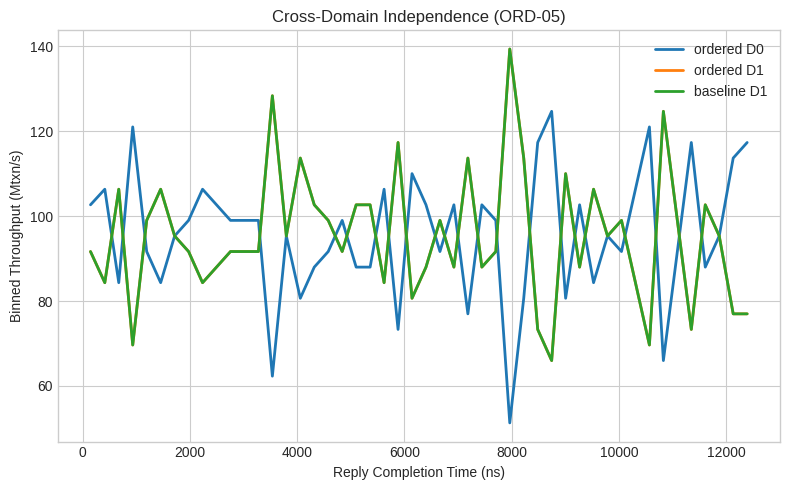

{'ordered_d1_vs_baseline_d1': np.float64(1.0)}


In [8]:
ord05 = tx[tx["experiment"] == "ORD-05"].copy()
positive_done = ord05["reply_done_ns"].dropna()
bins = max(12, min(48, len(positive_done) // 20))
ord05["time_bin"] = pd.cut(ord05["reply_done_ns"], bins=bins, labels=False, include_lowest=True)
_, edges = pd.cut(positive_done, bins=bins, retbins=True, include_lowest=True)
bin_width_ns = max(float(edges[1] - edges[0]), 1.0)
grouped = ord05.groupby(["run_tag", "ord_dom_id", "time_bin"]).size().reset_index(name="txn_count")
grouped["throughput_mtxns"] = grouped["txn_count"] / bin_width_ns * 1e3
grouped["time_mid_ns"] = grouped["time_bin"].astype(float).map(lambda idx: 0.5 * (edges[int(idx)] + edges[int(idx) + 1]))

plt.figure(figsize=(8, 5))
for run_tag, dom_id, label in [("ordered", 0, "ordered D0"), ("ordered", 1, "ordered D1"), ("baseline", 1, "baseline D1")]:
    view = grouped[(grouped["run_tag"] == run_tag) & (grouped["ord_dom_id"] == dom_id)].sort_values("time_mid_ns")
    if view.empty:
        continue
    plt.plot(view["time_mid_ns"], view["throughput_mtxns"], linewidth=2.0, label=label)
plt.xlabel("Reply Completion Time (ns)")
plt.ylabel("Binned Throughput (Mtxn/s)")
plt.title("Cross-Domain Independence (ORD-05)")
plt.legend()
out = plot_dir / "ordering_cross_domain_independence.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

domain1_ratio = grouped[(grouped["run_tag"] == "ordered") & (grouped["ord_dom_id"] == 1)]["throughput_mtxns"].mean() / grouped[(grouped["run_tag"] == "baseline") & (grouped["ord_dom_id"] == 1)]["throughput_mtxns"].mean()
print({"ordered_d1_vs_baseline_d1": domain1_ratio})


## Domain Blocking Timeline
This trace is the qualitative sanity check for the barrier FSM.
Expected behavior:
- domain 0 should show `younger_blocked=1` during the acquire/release window
- domain 1 should keep making progress instead of mirroring domain 0 stalls


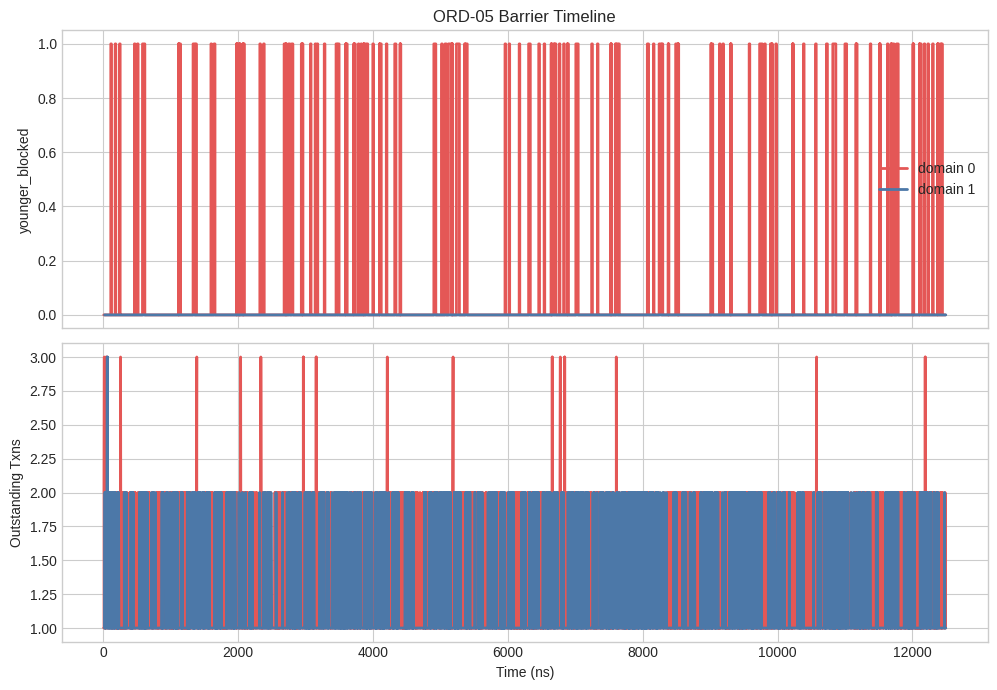

blocked     outstanding_txns    
                mean max             mean max
ord_dom_id                                   
0           0.093585   1         1.124603   3
1           0.000000   0         1.114478   3

In [9]:
ord05_trace = ord_dom[(ord_dom["experiment"] == "ORD-05") & (ord_dom["run_tag"] == "ordered")].copy()
ord05_trace["blocked"] = ord05_trace["younger_blocked"].astype(int)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for dom_id, color in [(0, "#e45756"), (1, "#4c78a8")]:
    view = ord05_trace[ord05_trace["ord_dom_id"] == dom_id].sort_values("time_ns")
    if view.empty:
        continue
    axes[0].step(view["time_ns"], view["blocked"], where="post", linewidth=2.0, label=f"domain {dom_id}", color=color)
    axes[1].plot(view["time_ns"], view["outstanding_txns"], linewidth=2.0, label=f"domain {dom_id}", color=color)
axes[0].set_ylabel("younger_blocked")
axes[0].set_title("ORD-05 Barrier Timeline")
axes[0].legend()
axes[1].set_xlabel("Time (ns)")
axes[1].set_ylabel("Outstanding Txns")
out = plot_dir / "ordering_domain_block_timeline.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

display(
    ord05_trace.groupby("ord_dom_id")[["blocked", "outstanding_txns"]].agg(["mean", "max"])
)


## OoO And Domain Count
This is the architecture-style parameter scan for how much ordering pressure OoO can hide once traffic is split across more domains.


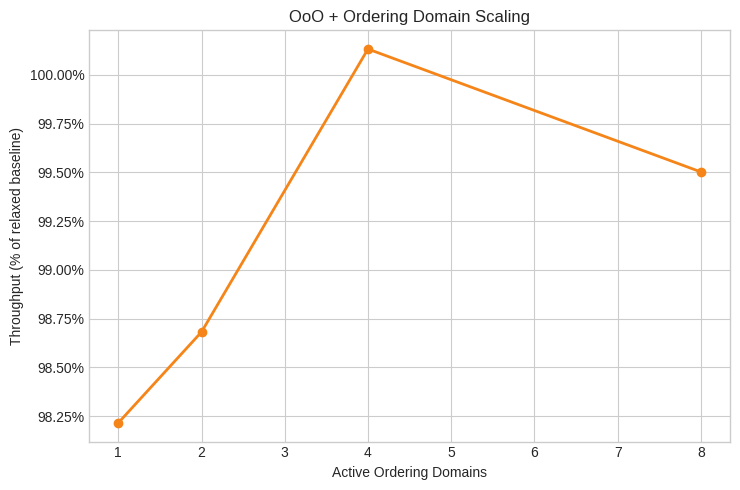

    param_value  normalized_throughput  avg_outstanding
17          1.0               0.982150         5.637321
18          2.0               0.986813         5.675893
19          4.0               1.001324         5.675179
20          8.0               0.995021         5.686429


In [10]:
domain_scan = scan[scan["family"] == "domain_scaling_ooo"].sort_values("param_value")
plt.figure(figsize=(7.5, 5))
plt.plot(domain_scan["param_value"], domain_scan["normalized_throughput"] * 100.0, marker="o", linewidth=2.0, color="#f58518")
plt.xlabel("Active Ordering Domains")
plt.ylabel("Throughput (% of relaxed baseline)")
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.title("OoO + Ordering Domain Scaling")
out = plot_dir / "ordering_domain_scaling_ooo.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

print(domain_scan[["param_value", "normalized_throughput", "avg_outstanding"]])


## Credit Utilization Timeline
This checks that a throughput drop is not coming from a hidden credit-model artifact.
If release drain is the root cause, utilization should move but not show a broken flatline or impossible spikes.


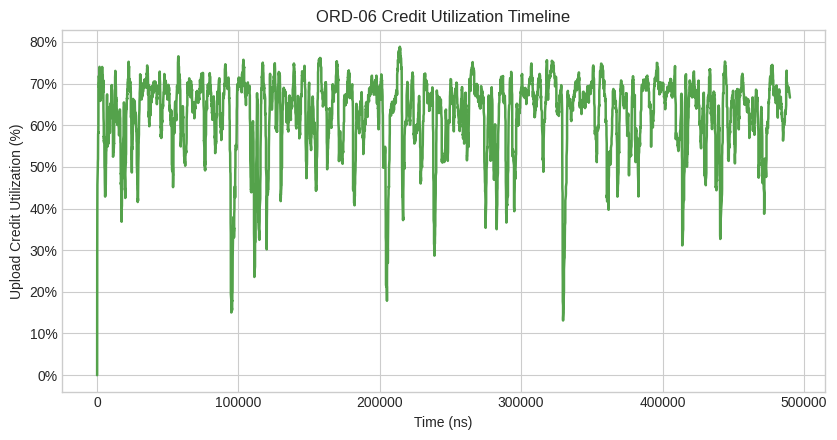

{'ord06_credit_util_mean': 0.6119466145833333, 'ord06_credit_util_peak': 0.8888888888888888}


In [11]:
ord06_credit = credit[(credit["experiment"] == "ORD-06") & (credit["run_tag"] == "ordered")].sort_values("time_ns").copy()
ord06_credit["util_smooth"] = ord06_credit["utilization"].rolling(window=64, min_periods=1).mean()
plt.figure(figsize=(8.5, 4.5))
plt.plot(ord06_credit["time_ns"], ord06_credit["util_smooth"] * 100.0, linewidth=1.8, color="#54a24b")
plt.xlabel("Time (ns)")
plt.ylabel("Upload Credit Utilization (%)")
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.title("ORD-06 Credit Utilization Timeline")
out = plot_dir / "ordering_credit_utilization_timeline.png"
plt.tight_layout()
plt.savefig(out, dpi=180)
plt.show()

print(
    {
        "ord06_credit_util_mean": float(ord06_credit["utilization"].mean()),
        "ord06_credit_util_peak": float(ord06_credit["utilization"].max()),
    }
)


## Correctness Checks
All six rule-oriented ordering checks should pass before using the performance curves as RTL guidance.


In [12]:
checks["passed"] = pd.to_numeric(checks["passed"], errors="coerce")
display(checks)
print({"all_checks_pass": bool((checks["passed"] == 1).all())})


,acquire_complete_ns,acquire_dispatch_ns,atomic_complete_ns,atomic_dispatch_ns,domains_checked,effect,expected_value,experiment,initial_reason,min_domain1_complete_ns,min_younger_complete_ns,min_younger_dispatch_ns,observed_value,older_complete_ns,passed,ready_after_older_complete,release_complete_ns,release_dispatch_ns,throughput_baseline,throughput_relaxed
0,NaN,NaN,NaN,NaN,NaN,younger same-domain traffic stays behind the r...,NaN,ORD-C01,NaN,NaN,0.0,0.0,NaN,NaN,1,NaN,0.0,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,release drains all older writes to visible ret...,NaN,ORD-C02,NaN,NaN,NaN,NaN,NaN,216.0,1,NaN,317.0,216.0,NaN,NaN
2,67.0,NaN,NaN,NaN,NaN,acquire blocks both issue and completion of yo...,NaN,ORD-C03,NaN,NaN,70.0,67.0,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
3,NaN,37.0,NaN,NaN,NaN,acquire observes state updated by the prior re...,2.779077e+09,ORD-C04,NaN,NaN,NaN,NaN,2.779077e+09,NaN,1,NaN,37.0,NaN,NaN,NaN
4,87.0,NaN,NaN,NaN,NaN,other domains continue while one domain is hel...,NaN,ORD-C05,NaN,13.0,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,101.0,37.0,NaN,same-domain atomic waits behind the release bo...,NaN,ORD-C06,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,37.0,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,release waits for accepted-but-not-yet-dispatc...,NaN,ORD-I02A,ord_release_wait,NaN,NaN,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,relaxed traffic sees zero modeled overhead fro...,NaN,ORD-I04,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,1.241765e+08,1.241765e+08
8,NaN,NaN,NaN,NaN,1.0,issued ord_epoch values remain monotonic withi...,NaN,ORD-I05,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN


{'all_checks_pass': True}


## Reference Figures (external)
These are style references for paper-grade plots, not target quantitative matches for this hub.

- Tail latency / distribution view: https://research.google/pubs/the-tail-at-scale/
- SIGCOMM latency-CDF style: https://people.csail.mit.edu/alizadeh/papers/homa-sigcomm18.pdf
- SIGCOMM throughput-vs-load style: https://people.csail.mit.edu/alizadeh/papers/dctcp-sigcomm10.pdf
- gem5 networking-style throughput comparison: https://networks.ece.cornell.edu/papers/dpdkgem5-ispass24.pdf
- HTSim simulator context: https://github.com/Broadcom/csg-htsim
